# THÊM DATA

In [ ]:
import pandas as pd
import requests
import io
import os

# try using a local CSV produced by the bot schedule first
local_csv = "btc_features.csv"
if os.path.exists(local_csv):
    data_raw = pd.read_csv(local_csv)
    print(f"Loaded local data from {local_csv}")
else:
    # Google Drive file ID from the sharing link
    file_id = '10XOY2JXYuRpoVTCZhO9nVouaueK-CjoB'

    # Construct the direct download URL
    download_url = f'https://drive.google.com/uc?export=download&id={file_id}'

    # Download the file content
    response = requests.get(download_url)
    response.raise_for_status()

    data_raw = pd.read_csv(io.StringIO(response.text))

# Đổi tên các cột sang tiếng Anh
data_raw = data_raw.rename(columns={
    'Ngày': 'Date',
    'Lần cuối': 'Close',
    'Mở': 'Open',
    'Cao': 'High',
    'Thấp': 'Low',
    'KL': 'Volume',
    '% Thay đổi': 'Change_Percent'
})

print("Thông tin dữ liệu: \n")
display(data_raw.info())

print("\nDữ liệu bảng:\n")
display(data_raw)

Thông tin dữ liệu: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1442 entries, 0 to 1441
Data columns (total 43 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   date                             1442 non-null   object 
 1   close                            1442 non-null   float64
 2   open                             1442 non-null   float64
 3   high                             1442 non-null   float64
 4   low                              1442 non-null   float64
 5   vol                              1442 non-null   float64
 6   zero_balance_addresses_all_time  1442 non-null   int64  
 7   unique_addresses_all_time        1442 non-null   int64  
 8   new_addresses                    1442 non-null   int64  
 9   active_addresses                 1442 non-null   int64  
 10  transaction_count                1442 non-null   int64  
 11  transaction_count_all_time       1442 non-null   int64  
 12 

None


Dữ liệu bảng:



,date,close,open,high,low,vol,zero_balance_addresses_all_time,unique_addresses_all_time,new_addresses,active_addresses,...,h_cp,macd_line_6_20,macd_signal_6_20,atr_14,obv,ema_5,sma_5,tema_5_8_13,stoch_k,stoch_d
0,2020-01-24,8437.5,8405.0,8522.9,8238.8,37920.0,588902973,617816103,399477,747701,...,113.1,276.173900,409.810584,331.716807,64660.0,8548.970810,8580.90,8185.356124,34.951627,27.277086
1,2020-01-27,8907.6,8621.3,9000.0,8585.0,49050.0,589928879,618849949,364842,714325,...,562.5,316.390584,391.126584,362.487899,113710.0,8668.513873,8634.06,8522.048039,87.861272,45.624176
2,2020-01-28,9367.0,8917.3,9389.0,8911.0,67140.0,590376436,619284302,434353,836582,...,481.4,421.276451,397.156557,378.342846,180850.0,8901.342582,8760.80,9062.731274,98.087289,73.633396
3,2020-01-29,9300.5,9396.2,9432.3,9256.6,49050.0,590785740,619710836,426534,792832,...,65.3,464.929864,410.711218,351.323800,131800.0,9034.395055,8884.48,9267.085552,88.956850,91.635137
4,2020-01-30,9513.3,9290.0,9576.4,9213.7,55440.0,591189123,620132694,421858,779424,...,275.9,521.023433,432.773661,352.840627,187240.0,9194.030036,9105.18,9507.379194,95.282596,94.108911
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1437,2025-08-08,116674.7,117472.0,117625.8,115926.0,10050.0,1398896575,1453370238,469211,949918,...,153.8,475.867950,957.758517,2785.177078,1892790.0,116147.955983,115664.76,116175.167561,80.651396,71.455748
1438,2025-08-11,118686.0,119302.2,122324.7,118231.8,26490.0,1399801155,1454370786,330574,768043,...,5650.0,919.478507,950.102515,3167.153467,1919280.0,116993.970655,116390.96,118166.089448,62.154038,79.923768
1439,2025-08-12,120147.6,118662.9,120324.4,118213.7,16720.0,1400128633,1454701882,331096,751605,...,1638.4,1459.545778,1051.991168,3026.293005,1936000.0,118045.180437,117594.52,120250.325804,75.728015,72.844483
1440,2025-08-13,123306.4,120081.1,123659.5,118950.4,23210.0,1400441905,1455050582,348700,752766,...,3511.9,2370.529503,1315.698835,3250.667271,1959210.0,119798.920291,119257.34,123615.126471,96.243817,78.041957


In [3]:
columns_to_keep = ['close', 'open', 'high', 'low', 'vol', 'rsi_14', 'macd_line_6_20', 'macd_signal_6_20', 'roc_12', 'atr_14', 'std_dev_20', 'obv']
data_final = data_raw[columns_to_keep]

print("Dữ liệu đã lọc với các cột được chọn:")
display(data_final.info())

Dữ liệu đã lọc với các cột được chọn:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1442 entries, 0 to 1441
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   close             1442 non-null   float64
 1   open              1442 non-null   float64
 2   high              1442 non-null   float64
 3   low               1442 non-null   float64
 4   vol               1442 non-null   float64
 5   rsi_14            1442 non-null   float64
 6   macd_line_6_20    1442 non-null   float64
 7   macd_signal_6_20  1442 non-null   float64
 8   roc_12            1442 non-null   float64
 9   atr_14            1442 non-null   float64
 10  std_dev_20        1442 non-null   float64
 11  obv               1442 non-null   float64
dtypes: float64(12)
memory usage: 135.3 KB


None

# Mô hình

In [4]:
!pip install stable-baselines3 gymnasium shimmy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 4.5 MB/s eta 0:00:00


In [5]:
import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import EvalCallback
import matplotlib.pyplot as plt

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [6]:
class BitcoinTradingEnv(gym.Env):
    def __init__(self, df, initial_balance=10000, window_size=20):
        super().__init__()
        self.df = df.reset_index(drop=True)
        self.initial_balance = initial_balance
        self.window_size = window_size
        self.n_features = df.shape[1]

        self.action_space = spaces.Discrete(3)
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf,
            shape=(window_size * self.n_features,), dtype=np.float32
        )

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = self.window_size
        self.balance = float(self.initial_balance)
        self.btc_held = 0.0
        self.net_worth = float(self.initial_balance)
        self.prev_net_worth = float(self.initial_balance)
        self.max_net_worth = float(self.initial_balance)
        self.trades = 0
        return self._get_obs(), {}

    def _get_obs(self):
        window = self.df.iloc[self.current_step - self.window_size:self.current_step].values.astype(np.float32)
        mean = window.mean(axis=0)
        std  = window.std(axis=0)
        std  = np.where(std < 1e-8, 1.0, std)   # ✅ avoid divide-by-zero / NaN
        obs  = (window - mean) / std
        obs  = np.nan_to_num(obs, nan=0.0, posinf=0.0, neginf=0.0)  # ✅ hard safety
        return obs.flatten().astype(np.float32)

    def step(self, action):
        price = float(self.df.iloc[self.current_step]['close'])

        # ✅ Guard against zero/NaN price
        if price <= 0 or np.isnan(price):
            price = 1e-8

        prev_worth = self.net_worth

        if action == 1 and self.balance >= price:   # Buy
            btc_bought = (self.balance * 0.95) / price
            self.btc_held += btc_bought
            self.balance -= btc_bought * price
            self.trades += 1
        elif action == 2 and self.btc_held > 0:     # Sell
            self.balance += self.btc_held * price
            self.btc_held = 0.0
            self.trades += 1

        self.net_worth = self.balance + self.btc_held * price
        self.max_net_worth = max(self.max_net_worth, self.net_worth)

        profit   = (self.net_worth - prev_worth) / (abs(prev_worth) + 1e-8)
        drawdown = (self.max_net_worth - self.net_worth) / (self.max_net_worth + 1e-8)
        reward   = float(np.clip(profit * 100 - drawdown * 10, -10, 10))  # ✅ clip reward

        self.current_step += 1
        done = self.current_step >= len(self.df) - 1

        return self._get_obs(), reward, done, False, {
            'net_worth': self.net_worth,
            'balance': self.balance
        }

In [7]:
from sklearn.preprocessing import RobustScaler  # ✅ more stable than MinMax for finance

scaler = RobustScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(data_final),
    columns=data_final.columns
)

# ✅ Final NaN/Inf check
df_scaled = df_scaled.replace([np.inf, -np.inf], np.nan).fillna(0)

split = int(len(df_scaled) * 0.8)
train_df = df_scaled.iloc[:split].reset_index(drop=True)
test_df  = df_scaled.iloc[split:].reset_index(drop=True)

print(f"Train: {len(train_df)} | Test: {len(test_df)}")
print(f"Any NaN: {df_scaled.isna().any().any()}")  # should print False

Train: 1153 | Test: 289
Any NaN: False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [8]:
import numpy as np
import random
import torch

SEED = 12 # Bạn có thể thay đổi số này để có các kết quả khác nhau nhưng vẫn có thể tái lập
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
print(f"Global seed set to {SEED}")

Global seed set to 12


In [ ]:
from stable_baselines3.common.utils import set_random_seed

set_random_seed(SEED)

train_env = DummyVecEnv([lambda: BitcoinTradingEnv(train_df, initial_balance=10000, window_size=20)])

model = PPO(
    "MlpPolicy",
    train_env,
    verbose=1,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,       # encourages exploration
    policy_kwargs=dict(net_arch=[256, 256, 128])
)

model.learn(total_timesteps=200_000)

# save using the configured path from the bot's config
import os
from config import PPO_BTC_MODEL_PATH
os.makedirs(os.path.dirname(PPO_BTC_MODEL_PATH), exist_ok=True)
# SB3 adds .zip extension automatically if missing
save_path = PPO_BTC_MODEL_PATH
if save_path.endswith('.zip'):
    save_path = save_path[:-4]
model.save(save_path)
print(f"✅ Model saved to {PPO_BTC_MODEL_PATH}")

Using cpu device
-----------------------------
| time/              |      |
|    fps             | 794  |
|    iterations      | 1    |
|    time_elapsed    | 2    |
|    total_timesteps | 2048 |
-----------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


------------------------------------------
| time/                   |              |
|    fps                  | 487          |
|    iterations           | 2            |
|    time_elapsed         | 8            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0057485015 |
|    clip_fraction        | 0.023        |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.1         |
|    explained_variance   | 0.000907     |
|    learning_rate        | 0.0003       |
|    loss                 | 4.41e+03     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.012       |
|    value_loss           | 1.11e+04     |
------------------------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 449         |
|    iterations           | 3           |
|    time_elapsed         | 13          |
|    total_times

In [10]:
env = BitcoinTradingEnv(test_df)
obs, _ = env.reset()
net_worths = [env.initial_balance]

done = False
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, _, info = env.step(action)
    net_worths.append(info['net_worth'])

final_worth = net_worths[-1]
roi = (final_worth - 10000) / 10000 * 100
print(f"- Final Net Worth: ${final_worth:,.2f}")
print(f"- ROI: {roi:.2f}%")
print(f"- Total Trades: {env.trades}")

- Final Net Worth: $28,574.07
- ROI: 185.74%
- Total Trades: 125


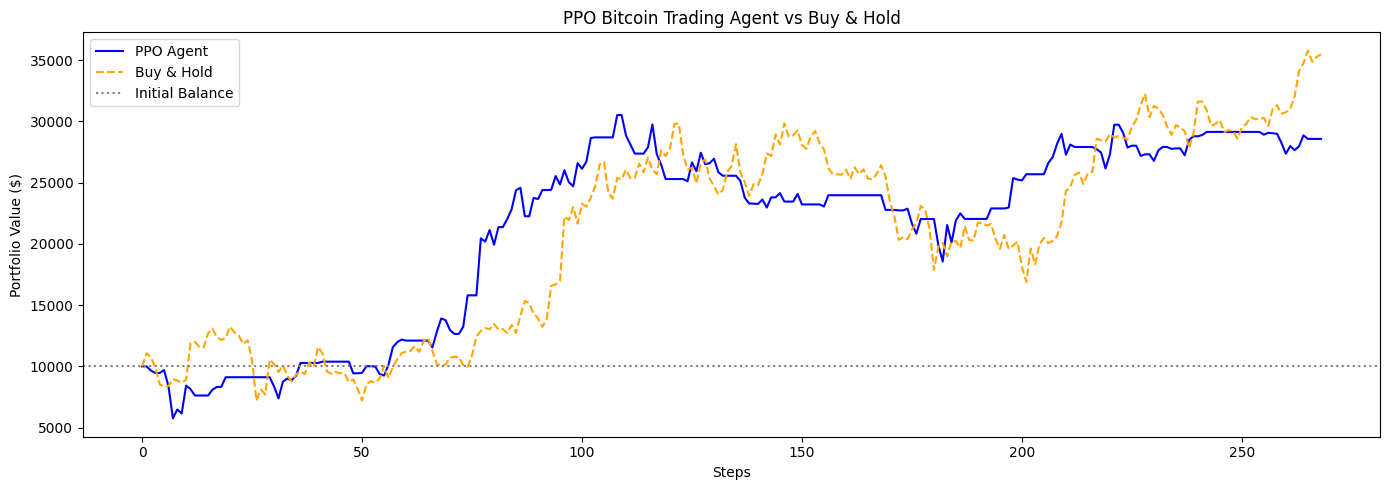

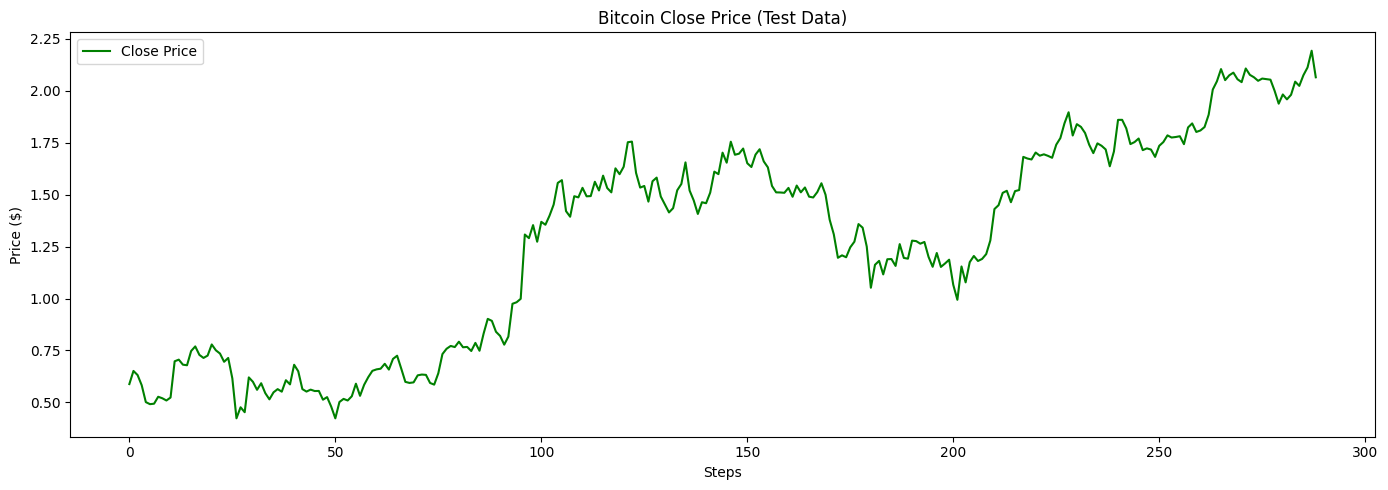

In [11]:
buy_hold = test_df['close'].values / test_df['close'].values[0] * 10000

plt.figure(figsize=(14, 5))
plt.plot(net_worths, label='PPO Agent', color='blue')
plt.plot(buy_hold[:len(net_worths)], label='Buy & Hold', color='orange', linestyle='--')
plt.axhline(10000, color='gray', linestyle=':', label='Initial Balance')
plt.title('PPO Bitcoin Trading Agent vs Buy & Hold')
plt.xlabel('Steps'); plt.ylabel('Portfolio Value ($)')
plt.legend(); plt.tight_layout(); plt.show()

# New plot for close price
plt.figure(figsize=(14, 5))
plt.plot(test_df['close'].values, label='Close Price', color='green')
plt.title('Bitcoin Close Price (Test Data)')
plt.xlabel('Steps'); plt.ylabel('Price ($)')
plt.legend(); plt.tight_layout(); plt.show()

In [12]:
import numpy as np

env = BitcoinTradingEnv(test_df)
obs, _ = env.reset()
net_worths = [env.initial_balance]

done = False
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, _, info = env.step(action)
    net_worths.append(info['net_worth'])

net_worths = np.array(net_worths)

# 1. Cumulative Return
cumulative_return = (net_worths[-1] - net_worths[0]) / net_worths[0] * 100
print(f"- Cumulative Return: {cumulative_return:.4f}")

# 2. Sharpe Ratio
daily_returns = np.diff(net_worths) / (net_worths[:-1] + 1e-8)
sharpe_ratio = (daily_returns.mean() / (daily_returns.std() + 1e-8)) * np.sqrt(365)
print(f"- Sharpe Ratio: {sharpe_ratio:.4f}")

# 3. Max Drawdown
rolling_max = np.maximum.accumulate(net_worths)
drawdowns = (rolling_max - net_worths) / (rolling_max + 1e-8)
max_drawdown = drawdowns.max() * 100
print(f"- Max Drawdown: {max_drawdown:.2f}%")

# 4. Calmar Ratio

initial_value = net_worths[0]
final_value = net_worths[-1]
num_days = len(net_worths) - 1
total_years = num_days / 365.0

if total_years > 0:
    cagr = ((final_value / initial_value) ** (1 / total_years)) - 1
else:
    cagr = 0

max_drawdown_decimal = max_drawdown / 100

if max_drawdown_decimal != 0:
    calmar_ratio = cagr / abs(max_drawdown_decimal)
else:
    calmar_ratio = np.nan

print(f"- Calmar Ratio: {calmar_ratio:.4f}")

- Cumulative Return: 185.7407
- Sharpe Ratio: 1.9020
- Max Drawdown: 42.48%
- Calmar Ratio: 7.4829
